<a href="https://colab.research.google.com/github/cduplan59/CFT_analysis/blob/main/Inflation_notebook_V3_2_targeted_scan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Fractal to Classical Spacetime Transition:
IFS, DSI, and a Hausdorff Sigmoid toward FLRW
— notebook V3.2 (notation Ŧ)

This version V3.2 explicitly adopts **Ŧ** as the local connection clock to avoid ambiguity with the symbol \(\theta\) in the rest of the study.

## Logic of V3.2
The notebook is organized into three sections:

1. **Geometric burst**
   \[
   H_D^{eff}(Ŧ)=H_D^{bg}(\Delta\tau_\odot(Ŧ))+B_{inf}(Ŧ)+g_\xi(Ŧ)\,\xi(\Delta\tau_\odot(Ŧ)).
   \]

2. **Local kinematics**
   \[
   H(Ŧ)=\frac{H_D^{eff}(Ŧ)}{6\,\beta(Ŧ)\,Ŧ}.
   \]

3. **Detection of a plateau core**
   The matrices are no longer constructed over the entire inflationary window, but over an **admissible subwindow** defined by:
   - \(0<\epsilon_1<1\),
   - \(B_{inf}(T)\) close to the plateau,
   - \(|\epsilon_2|\) bounded,
   - adiabaticity diagnostics satisfied.

## Status
This notebook does not attempt to derive \(n_s\) and \(r\) microscopically from a fundamental canonical slow-roll.  
It is used to populate:
- a **geometric matrix**,
- a **kinematic pivot matrix**,
- a **robustness matrix**.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.optimize import brentq

## Constants and Minimum Targets

In [2]:
Mpl_red = 2.435e18
hbar_GeV_s = 6.582119569e-25

Nstar_scan_min = 20.0
Nstar_scan_max = 70.0
Nstar_CMB_min = 54.0
Nstar_CMB_max = 60.0

## Model Parameters

In [3]:
p = {
    "Tbar_min": 1e-44,
    "Tbar_max": 1e-34,
    "t_cross": 5.0e-40,
    "tau_reg": 1.0e-40,

    "delta_tau_min": 1e-6,
    "delta_tau_max": 1e+2,

    "H_uv": 6.0,
    "H_ir": 3.0,
    "HD_delta_tau_c": 1.0,
    "HD_delta_tau_w": 0.35,

    "xi_amp": 0.08,
    "xi_damp": 0.25,
    "xi_omega": 8.0,
    "xi_phi": 0.0,
    "delta_tau_ref": 1.0,

    "Tbar_xi": 3.0e-40,
    "Delta_xi_log": 0.60,

    "HB_target": 29.0,
    "Tbar_on": 1.0e-40,
    "Tbar_off": 1.0e-36,
    "Tbar_w": 0.35,

    "beta_lo": 1.05,
    "beta_hi": 1.18,
    "beta_Tbar_c": 1.0e-38,
    "beta_Tbar_w": 0.60,

    "A_HD_max": 0.25,
    "A_beta_max": 0.25,
    "eps2_max": 0.50,
    "eps2_core_max": 0.15,
}

## Geometry, Burst, and Local Clock Ŧ

In [4]:
def t_of_Tbar(Tbar, p):
    return p["t_cross"] - p["tau_reg"] + Tbar

def delta_tau_of_Tbar(Tbar, p):
    Tmin, Tmax = p["Tbar_min"], p["Tbar_max"]
    dmin, dmax = p["delta_tau_min"], p["delta_tau_max"]
    th = np.clip(Tbar, Tmin, Tmax)
    u = (np.log(th) - np.log(Tmin)) / (np.log(Tmax) - np.log(Tmin))
    return np.exp(np.log(dmin) + u * (np.log(dmax) - np.log(dmin)))

def H_D_background(delta_tau, p):
    dt = np.clip(delta_tau, p["delta_tau_min"], p["delta_tau_max"])
    x = (dt - p["HD_delta_tau_c"]) / p["HD_delta_tau_w"]
    s = 0.5 * (1.0 + np.tanh(x))
    return p["H_uv"] + (p["H_ir"] - p["H_uv"]) * s

def xi_DSI(delta_tau, p):
    dt = np.clip(delta_tau, p["delta_tau_min"], p["delta_tau_max"])
    X = np.log(dt / max(p["delta_tau_ref"], 1e-30))
    return p["xi_amp"] * np.exp(-p["xi_damp"] * np.abs(X)) * np.cos(p["xi_omega"] * X + p["xi_phi"])

def g_xi_of_Tbar(Tbar, p):
    th = np.clip(Tbar, p["Tbar_min"], p["Tbar_max"])
    txi = max(p["Tbar_xi"], p["Tbar_min"])
    D = p["Delta_xi_log"]
    return 0.5 * (1.0 - np.tanh((np.log(th) - np.log(txi)) / D))

def burst_window(Tbar, p):
    th = np.clip(Tbar, p["Tbar_min"], p["Tbar_max"])
    X = np.log(th)
    Xon = np.log(p["Tbar_on"])
    Xoff = np.log(p["Tbar_off"])
    sig = p["Tbar_w"]
    left = 0.5 * (1.0 + np.tanh((X - Xon) / sig))
    right = 0.5 * (1.0 + np.tanh((X - Xoff) / sig))
    return np.clip(left - right, 0.0, 1.0)

def B_inf(Tbar, p):
    return (p["HB_target"] - p["H_uv"]) * burst_window(Tbar, p)

def beta_of_Tbar(Tbar, p):
    th = np.clip(Tbar, p["Tbar_min"], p["Tbar_max"])
    th_c = max(p["beta_Tbar_c"], p["Tbar_min"])
    X = (np.log(th) - np.log(th_c)) / p["beta_Tbar_w"]
    s = 0.5 * (1.0 + np.tanh(X))
    return p["beta_lo"] + (p["beta_hi"] - p["beta_lo"]) * s

def H_D_bg_of_Tbar(Tbar, p):
    return H_D_background(delta_tau_of_Tbar(Tbar, p), p)

def xi_of_Tbar(Tbar, p):
    return xi_DSI(delta_tau_of_Tbar(Tbar, p), p)

def H_D_eff_of_Tbar(Tbar, p):
    th = np.clip(Tbar, p["Tbar_min"], p["Tbar_max"])
    return H_D_bg_of_Tbar(th, p) + B_inf(th, p) + g_xi_of_Tbar(th, p) * xi_of_Tbar(th, p)

def Xi_struct_of_Tbar(Tbar, p):
    th = np.clip(Tbar, p["Tbar_min"], p["Tbar_max"])
    return abs(g_xi_of_Tbar(th, p) * xi_of_Tbar(th, p))

def H_of_Tbar(Tbar, p):
    th = np.clip(Tbar, p["Tbar_min"], p["Tbar_max"])
    return H_D_eff_of_Tbar(th, p) / (6.0 * beta_of_Tbar(th, p) * th)

def H_to_GeV(H_si):
    return hbar_GeV_s * H_si

def rho_from_H_GeV(H_GeV):
    return 3.0 * (Mpl_red ** 2) * (H_GeV ** 2)

## Derivatives and Diagnostics

In [5]:
def d_dTbar(func, Tbar, p, rel_step=1e-3):
    lo = p["Tbar_min"] * (1.0 + 1e-12)
    hi = p["Tbar_max"] * (1.0 - 1e-12)
    th = float(np.clip(Tbar, lo, hi))
    tp = min(th * (1.0 + rel_step), hi)
    tm = max(th / (1.0 + rel_step), lo)
    if tp <= tm:
        return np.nan
    return (func(tp, p) - func(tm, p)) / (tp - tm)

def p_eff_of_Tbar(Tbar, p):
    th = np.clip(Tbar, p["Tbar_min"], p["Tbar_max"])
    return H_D_eff_of_Tbar(th, p) / (6.0 * beta_of_Tbar(th, p))

def epsilon1_of_Tbar(Tbar, p):
    th = np.clip(Tbar, p["Tbar_min"], p["Tbar_max"])
    peff = p_eff_of_Tbar(th, p)
    dpeff = d_dTbar(p_eff_of_Tbar, th, p)
    if not np.isfinite(peff) or peff <= 0:
        return np.nan
    return 1.0 / peff - th * dpeff / (peff ** 2)

def epsilon2_of_Tbar(Tbar, p):
    th = np.clip(Tbar, p["Tbar_min"], p["Tbar_max"])
    eps1 = epsilon1_of_Tbar(th, p)
    if not np.isfinite(eps1) or eps1 <= 0:
        return np.nan
    deps1 = d_dTbar(lambda x, pp: epsilon1_of_Tbar(x, pp), th, p)
    H = H_of_Tbar(th, p)
    return deps1 / (H * eps1)

def A_HD_of_Tbar(Tbar, p):
    HDeff = H_D_eff_of_Tbar(Tbar, p)
    dHDeff = d_dTbar(lambda x, pp: H_D_eff_of_Tbar(x, pp), Tbar, p)
    H = H_of_Tbar(Tbar, p)
    if not np.isfinite(HDeff) or HDeff <= 0:
        return np.nan
    return abs(dHDeff / (H * HDeff))

def A_beta_of_Tbar(Tbar, p):
    beta = beta_of_Tbar(Tbar, p)
    dbeta = d_dTbar(beta_of_Tbar, Tbar, p)
    H = H_of_Tbar(Tbar, p)
    if not np.isfinite(beta) or beta <= 0:
        return np.nan
    return abs(dbeta / (H * beta))

def adiabatic_ok(Tbar, p):
    Ahd = A_HD_of_Tbar(Tbar, p)
    Ab = A_beta_of_Tbar(Tbar, p)
    eps2 = abs(epsilon2_of_Tbar(Tbar, p))
    return (
        np.isfinite(Ahd) and Ahd <= p["A_HD_max"] and
        np.isfinite(Ab) and Ab <= p["A_beta_max"] and
        np.isfinite(eps2) and eps2 <= p["eps2_max"]
    )

## Identifying the inflationary window and the plateau phase

In [6]:
def _intervals_from_mask(grid, mask):
    intervals = []
    start = None
    for i, ok in enumerate(mask):
        if ok and start is None:
            start = i
        if start is not None and (i == len(mask) - 1 or not mask[i + 1]):
            intervals.append((start, i))
            start = None
    return intervals

def _longest_interval(grid, mask):
    intervals = _intervals_from_mask(grid, mask)
    if not intervals:
        raise ValueError("No valid interval detected.")
    best = max(intervals, key=lambda ij: np.log(grid[ij[1]] / grid[ij[0]]))
    return grid[best[0]], grid[best[1]]

Tbar_grid = np.logspace(np.log10(p["Tbar_min"]), np.log10(p["Tbar_max"]), 1200)

eps1_vals = np.array([epsilon1_of_Tbar(x, p) for x in Tbar_grid])
eps2_vals = np.array([epsilon2_of_Tbar(x, p) for x in Tbar_grid])
HDe_vals = np.array([H_D_eff_of_Tbar(x, p) for x in Tbar_grid])
B_vals = np.array([B_inf(x, p) for x in Tbar_grid])
Ahd_vals = np.array([A_HD_of_Tbar(x, p) for x in Tbar_grid])
Ab_vals = np.array([A_beta_of_Tbar(x, p) for x in Tbar_grid])

mask_infl = np.isfinite(eps1_vals) & (eps1_vals > 0.0) & (eps1_vals < 1.0)
mask_core = mask_infl & np.isfinite(eps2_vals) & np.isfinite(Ahd_vals) & np.isfinite(Ab_vals)
mask_core &= (B_vals > 0.8 * np.nanmax(B_vals))
mask_core &= (np.abs(eps2_vals) < p["eps2_core_max"])
mask_core &= (Ahd_vals < p["A_HD_max"]) & (Ab_vals < p["A_beta_max"])

Tbar_in, Tbar_out = _longest_interval(Tbar_grid, mask_infl)
Tbar_core_in, Tbar_core_out = _longest_interval(Tbar_grid, mask_core)

def N_between(Tbar_a, Tbar_b, p):
    a = max(Tbar_a, p["Tbar_min"])
    b = min(Tbar_b, p["Tbar_max"])
    if a >= b:
        return 0.0
    x1, x2 = np.log(a), np.log(b)
    integrand = lambda x: H_of_Tbar(np.exp(x), p) * np.exp(x)
    val, _ = quad(integrand, x1, x2, limit=400)
    return val

N_infl_available = N_between(Tbar_in, Tbar_out, p)
N_core_available = N_between(Tbar_core_in, Tbar_core_out, p)

print("Ŧ_in =", Tbar_in)
print("Ŧ_out =", Tbar_out)
print("Ŧ_core,in =", Tbar_core_in)
print("Ŧ_core,out =", Tbar_core_out)
print("N_infl_available =", N_infl_available)
print("N_core_available =", N_core_available)

Ŧ_in = 1.2447416817545941e-40
Ŧ_out = 8.708632387179064e-37
Ŧ_core,in = 1.863052904790002e-40
Ŧ_core,out = 5.18516166952213e-37
N_infl_available = 37.625071332234754
N_core_available = 34.20398599847842


## Diagnostic global du burst

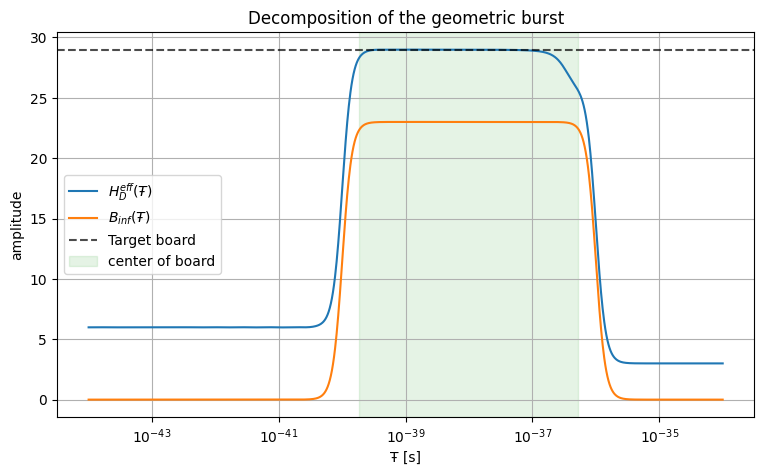

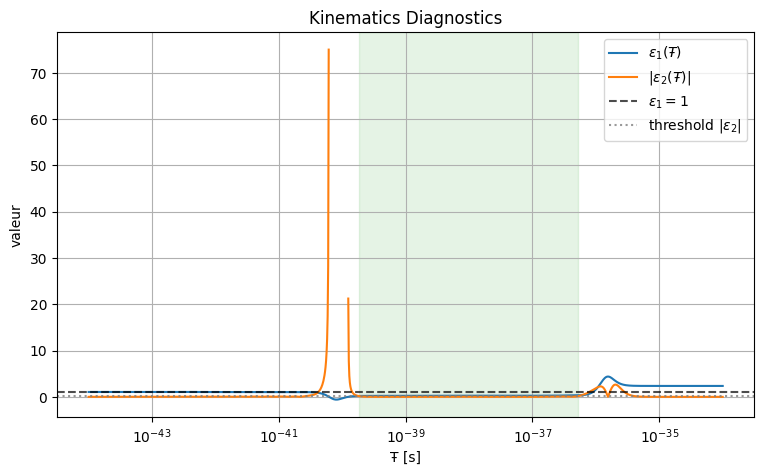

Max tray H_D^eff = 28.990260786482803
min epsilon1 = -0.59738480067614
max epsilon1 = 4.389834928044404


In [7]:
plt.figure(figsize=(9,5))
plt.semilogx(Tbar_grid, HDe_vals, label=r"$H_D^{eff}(Ŧ)$")
plt.semilogx(Tbar_grid, B_vals, label=r"$B_{inf}(Ŧ)$")
plt.axhline(p["HB_target"], ls="--", color="k", alpha=0.7, label="Target board")
plt.axvspan(Tbar_core_in, Tbar_core_out, color="tab:green", alpha=0.12, label="center of board")
plt.xlabel("Ŧ [s]")
plt.ylabel("amplitude")
plt.title("Decomposition of the geometric burst")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(9,5))
plt.semilogx(Tbar_grid, eps1_vals, label=r"$\epsilon_1(Ŧ)$")
plt.semilogx(Tbar_grid, np.abs(eps2_vals), label=r"$|\epsilon_2(Ŧ)|$")
plt.axhline(1.0, ls="--", color="k", alpha=0.7, label=r"$\epsilon_1=1$")
plt.axhline(p["eps2_core_max"], ls=":", color="gray", alpha=0.8, label=r"threshold $|\epsilon_2|$")
plt.axvspan(Tbar_core_in, Tbar_core_out, color="tab:green", alpha=0.12)
plt.xlabel("Ŧ [s]")
plt.ylabel("valeur")
plt.title("Kinematics Diagnostics")
plt.grid(True)
plt.legend()
plt.show()

print("Max tray H_D^eff =", float(np.nanmax(HDe_vals)))
print("min epsilon1 =", float(np.nanmin(eps1_vals)))
print("max epsilon1 =", float(np.nanmax(eps1_vals)))

## Table 1 — Geometry of the inflationary window

In [8]:
tableau1 = pd.DataFrame([
    {
        "domain": "inflationnary window",
        "Ŧ_in [s]": Tbar_in,
        "Ŧ_out [s]": Tbar_out,
        "t_in [s]": t_of_Tbar(Tbar_in, p),
        "t_out [s]": t_of_Tbar(Tbar_out, p),
        "H_in [GeV]": H_to_GeV(H_of_Tbar(Tbar_in, p)),
        "H_out [GeV]": H_to_GeV(H_of_Tbar(Tbar_out, p)),
        "N_disponible": N_infl_available,
    },
    {
        "domain": "center of board",
        "Ŧ_in [s]": Tbar_core_in,
        "Ŧ_out [s]": Tbar_core_out,
        "t_in [s]": t_of_Tbar(Tbar_core_in, p),
        "t_out [s]": t_of_Tbar(Tbar_core_out, p),
        "H_in [GeV]": H_to_GeV(H_of_Tbar(Tbar_core_in, p)),
        "H_out [GeV]": H_to_GeV(H_of_Tbar(Tbar_core_out, p)),
        "N_available": N_core_available,
    },
])
tableau1

,domain,Ŧ_in [s],Ŧ_out [s],t_in [s],t_out [s],H_in [GeV],H_out [GeV],N_disponible,N_available
0,inflationnary window,1.244742e-40,8.708632e-37,5.244742e-40,8.712632e-37,2.005031e+16,2.009432e+12,37.625071,NaN
1,center of board,1.863053e-40,5.185162e-37,5.863053e-40,5.189162e-37,1.589156e+16,4.598847e+12,NaN,34.203986


## Table 2 — Kinematic pivot scan of the hub

In [9]:
def find_Tbar_star_from_N(N_target, Tbar_core_in, Tbar_core_out, p):
    a = max(Tbar_core_in, p["Tbar_min"] * (1.0 + 1e-12))
    b = min(Tbar_core_out, p["Tbar_max"] * (1.0 - 1e-12))
    xa, xb = np.log(a), np.log(b)

    f = lambda x: N_between(np.exp(x), b, p) - N_target
    x_star = brentq(f, xa, xb)
    return float(np.exp(x_star))

rows = []
for N_star in np.arange(Nstar_scan_min, min(Nstar_scan_max, np.floor(N_core_available)) + 1):
    Tbar_star = find_Tbar_star_from_N(N_star, Tbar_core_in, Tbar_core_out, p)
    H_star_GeV = H_to_GeV(H_of_Tbar(Tbar_star, p))
    rows.append({
        "N_*": float(N_star),
        "Ŧ_* [s]": Tbar_star,
        "t_* [s]": t_of_Tbar(Tbar_star, p),
        "H_* [GeV]": H_star_GeV,
        "V_*^(1/4) [GeV]": rho_from_H_GeV(H_star_GeV)**0.25,
        "Xi_struct": Xi_struct_of_Tbar(Tbar_star, p),
        "eps1_eff": epsilon1_of_Tbar(Tbar_star, p),
        "eps2_eff": epsilon2_of_Tbar(Tbar_star, p),
        "adiabatic": adiabatic_ok(Tbar_star, p),
        "in_window_54_60": bool((N_star >= Nstar_CMB_min) and (N_star <= Nstar_CMB_max)),
    })

tableau2 = pd.DataFrame(rows)
tableau2.head(10)

,N_*,Ŧ_* [s],t_* [s],H_* [GeV],V_*^(1/4) [GeV],Xi_struct,eps1_eff,eps2_eff,adiabatic,in_window_54_60
0,20.0,4.105208e-39,4.505208e-39,7.333144e+14,5.561282e+16,0.000005,0.222829,0.016427,True,False
1,21.0,3.300194e-39,3.700194e-39,9.149789e+14,6.212056e+16,0.000007,0.220111,0.008779,True,False
2,22.0,2.654321e-39,3.054321e-39,1.139370e+15,6.932057e+16,0.000015,0.218706,0.004471,True,False
3,23.0,2.135363e-39,2.535363e-39,1.417350e+15,7.731581e+16,0.000036,0.218001,0.002239,True,False
4,24.0,1.718073e-39,2.118073e-39,1.762255e+15,8.621129e+16,0.000032,0.217651,0.001106,True,False
5,25.0,1.382408e-39,1.782408e-39,2.190544e+15,9.611824e+16,0.000161,0.217483,0.000488,True,False
6,26.0,1.112355e-39,1.512355e-39,2.722619e+15,1.071577e+17,0.000010,0.217416,0.000191,True,False
7,27.0,8.950722e-40,1.295072e-39,3.383766e+15,1.194621e+17,0.000624,0.217371,0.000288,True,False
8,28.0,7.202390e-40,1.120239e-39,4.205188e+15,1.331749e+17,0.000391,0.217280,0.000500,True,False
9,29.0,5.795503e-40,9.795503e-40,5.225525e+15,1.484550e+17,0.001986,0.217214,-0.000070,True,False


## Table 3 — Geometric robustness

In [11]:
def compute_geometry_block(par):
    grid = np.logspace(np.log10(par["Tbar_min"]), np.log10(par["Tbar_max"]), 900)
    e1 = np.array([epsilon1_of_Tbar(x, par) for x in grid])
    e2 = np.array([epsilon2_of_Tbar(x, par) for x in grid])
    Hde = np.array([H_D_eff_of_Tbar(x, par) for x in grid])
    Bv = np.array([B_inf(x, par) for x in grid])
    Ahd = np.array([A_HD_of_Tbar(x, par) for x in grid])
    Ab = np.array([A_beta_of_Tbar(x, par) for x in grid])

    infl = np.isfinite(e1) & (e1 > 0.0) & (e1 < 1.0)
    core = infl & np.isfinite(e2) & np.isfinite(Ahd) & np.isfinite(Ab)
    core &= (Bv > 0.8 * np.nanmax(Bv))
    core &= (np.abs(e2) < par["eps2_core_max"])
    core &= (Ahd < par["A_HD_max"]) & (Ab < par["A_beta_max"])

    Tin, Tout = _longest_interval(grid, infl)
    Tcin, Tcout = _longest_interval(grid, core)

    N_infl = N_between(Tin, Tout, par)
    N_core = N_between(Tcin, Tcout, par)

    return {
        "HB_target": par["HB_target"],
        "Ŧ_on [s]": par["Tbar_on"],
        "Ŧ_off [s]": par["Tbar_off"],
        "Ŧ_max [s]": par["Tbar_max"],
        "beta_lo": par["beta_lo"],
        "beta_hi": par["beta_hi"],
        "Ŧ_in [s]": Tin,
        "Ŧ_out [s]": Tout,
        "Ŧ_core,in [s]": Tcin,
        "Ŧ_core,out [s]": Tcout,
        "N_infl": N_infl,
        "N_core": N_core,
        "max H_D^eff": float(np.nanmax(Hde)),
        "min eps1": float(np.nanmin(e1)),
        "max eps1": float(np.nanmax(e1)),
        "max |eps2| core": float(np.nanmax(np.abs(e2[core]))) if np.any(core) else np.nan,
        "adiabatique_core": bool(np.any(core)),
        "supporte_54_60_core": bool(N_core >= 54.0),
    }

rows = []
for Tbar_on in [2e-41, 3e-41, 1e-40]:
    for Tbar_off in [1e-36, 3e-36, 1e-35, 3e-35]:
        for Tbar_max in [1e-34, 3e-34, 1e-33]:
            for beta_lo, beta_hi in [(1.05, 1.18), (1.02, 1.12), (1.00, 1.10), (0.98, 1.08)]:
                par = dict(p)
                par["Tbar_on"] = Tbar_on
                par["Tbar_off"] = Tbar_off
                par["Tbar_max"] = Tbar_max
                par["beta_lo"] = beta_lo
                par["beta_hi"] = beta_hi
                rows.append(compute_geometry_block(par))

tableau3 = pd.DataFrame(rows).sort_values(
    ["supporte_54_60_core", "N_core", "N_infl"],
    ascending=[False, False, False]
).reset_index(drop=True)

print("Top 15 configurations :")
print(tableau3.head(15))
tableau3.head(15)


Top 15 configurations :
    HB_target      Ŧ_on [s]     Ŧ_off [s]     Ŧ_max [s]  beta_lo  beta_hi  \
0        29.0  2.000000e-41  3.000000e-35  1.000000e-33     0.98     1.08   
1        29.0  2.000000e-41  3.000000e-35  3.000000e-34     0.98     1.08   
2        29.0  2.000000e-41  3.000000e-35  1.000000e-34     0.98     1.08   
3        29.0  2.000000e-41  3.000000e-35  1.000000e-33     1.00     1.10   
4        29.0  2.000000e-41  3.000000e-35  3.000000e-34     1.00     1.10   
5        29.0  3.000000e-41  3.000000e-35  1.000000e-33     0.98     1.08   
6        29.0  2.000000e-41  3.000000e-35  1.000000e-34     1.00     1.10   
7        29.0  2.000000e-41  3.000000e-35  1.000000e-33     1.02     1.12   
8        29.0  3.000000e-41  3.000000e-35  3.000000e-34     0.98     1.08   
9        29.0  2.000000e-41  3.000000e-35  3.000000e-34     1.02     1.12   
10       29.0  3.000000e-41  3.000000e-35  1.000000e-34     0.98     1.08   
11       29.0  2.000000e-41  3.000000e-35  1.000000e

,HB_target,Ŧ_on [s],Ŧ_off [s],Ŧ_max [s],beta_lo,beta_hi,Ŧ_in [s],Ŧ_out [s],"Ŧ_core,in [s]","Ŧ_core,out [s]",N_infl,N_core,max H_D^eff,min eps1,max eps1,max |eps2| core,adiabatique_core,supporte_54_60_core
0,29.0,2.000000e-41,3.000000e-35,1.000000e-33,0.98,1.08,2.520910e-41,2.715285e-35,3.739889e-41,1.502668e-35,63.124429,59.214899,29.001839,-0.551437,4.017518,0.147399,True,True
1,29.0,2.000000e-41,3.000000e-35,3.000000e-34,0.98,1.08,2.462469e-41,2.680672e-35,3.682847e-41,1.485427e-35,62.769058,58.828301,29.003545,-0.556729,4.015300,0.145743,True,True
2,29.0,2.000000e-41,3.000000e-35,1.000000e-34,0.98,1.08,2.469781e-41,2.708339e-35,3.720780e-41,1.502668e-35,62.406612,58.446330,29.005147,-0.553709,4.017518,0.147399,True,True
3,29.0,2.000000e-41,3.000000e-35,1.000000e-33,1.00,1.10,2.520910e-41,2.639852e-35,3.739889e-41,1.460923e-35,61.846565,57.979432,29.001839,-0.562691,4.091916,0.140558,True,True
4,29.0,2.000000e-41,3.000000e-35,3.000000e-34,1.00,1.10,2.462469e-41,2.680672e-35,3.682847e-41,1.485427e-35,61.574796,57.709004,29.003545,-0.568091,4.089657,0.148718,True,True
5,29.0,3.000000e-41,3.000000e-35,1.000000e-33,0.98,1.08,3.739889e-41,2.715285e-35,5.548303e-41,1.502668e-35,61.170106,57.268857,28.997918,-0.556166,4.017518,0.147399,True,True
6,29.0,2.000000e-41,3.000000e-35,1.000000e-34,1.00,1.10,2.469781e-41,2.639852e-35,3.720780e-41,1.464670e-35,61.148531,57.234738,29.005147,-0.565009,4.091916,0.142805,True,True
7,29.0,2.000000e-41,3.000000e-35,1.000000e-33,1.02,1.12,2.520910e-41,2.639852e-35,3.739889e-41,1.460923e-35,60.692298,56.897313,29.001839,-0.573944,4.166315,0.143369,True,True
8,29.0,3.000000e-41,3.000000e-35,3.000000e-34,0.98,1.08,3.783013e-41,2.680672e-35,5.657841e-41,1.485427e-35,60.672769,56.714581,29.002989,-0.552471,4.015300,0.138820,True,True
9,29.0,2.000000e-41,3.000000e-35,3.000000e-34,1.02,1.12,2.462469e-41,2.680672e-35,3.783013e-41,1.485427e-35,60.425218,56.507293,29.003545,-0.579453,4.164014,0.143961,True,True


## Export CSV

In [12]:
# tableau1.to_csv("V3_2_tableau1_geometrie.csv", index=False)
#tableau2.to_csv("V3_2_tableau2_pivot.csv", index=False)
tableau3.to_csv("V3_2_tableau3_robustesse_scan.csv", index=False)

print("Exports créés :")
#print("-  V3_2_tableau1_geometry.csv")
#print("- V3_2_tableau2_pivot.csv")
print("- V3_2_tableau3_robustness_scan.csv")

Exports créés :
- V3_2_tableau3_robustness_scan.csv
